In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import combinations
import scanpy as sc

import sys
sys.path.append('../../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
import os

large_data_dir = gf_utils.large_data_dir


In [ ]:
### First add all of mutations in the feature set across all patients to every patient but only allowing wt calls because that mutation was not significant in that patient. This is so we get wt genotypes in the final adata even for patients that were not mutated in these genes

feature_set = 'feature_set_all.csv'
alt_gapfill_set = pd.read_csv(feature_set)

lib = 'GBM'

os.system('mkdir output/likelihood_tables_with_null_' + lib)
BC = 'BC002'

### first get probe_reads to use for the patient
adata_path = large_data_dir + 'GBM_' + BC + '_genotyped.h5ad' ### this is just for cell names; it would not usually use the genotyped h5ad because it wouldn't be generated yet, but cell names are the same so we use it here to not have to upload a redundant h5ad just for this step
gf_dir = large_data_dir + 'gf_decrosslink_4plex/BC' + str(int(BC.replace('BC',''))) + '_giftwrap/'
            
min_percent_supporting = 0.9
collapse_across_probes = True
probe_reads = gf_utils.get_input_probe_reads(gf_dir, read_threshold = 0, adata_path = adata_path, min_percent_supporting=min_percent_supporting, collapse_across_probes=collapse_across_probes)

sample = BC + '_' + lib

null_set = pd.DataFrame()
sample = BC + '_' + lib
temp = alt_gapfill_set[alt_gapfill_set['sample'] != sample][['name','HGVSc','gapfill','gapfill_from_transcriptome','original_name']].drop_duplicates()
temp['sample'] = sample
null_set = pd.concat([null_set, temp])
try:
    gapfill_likelihoods = pd.read_csv('output/likelihood_tables_' + lib + '/' + BC + '_gapfill_likelihoods.csv')
except FileNotFoundError:
    print('WARNING: gapfill likelihoods file not found for ' + sample + ')')
    gapfill_likelihoods = pd.DataFrame()
    gapfill_likelihoods['probe_idx'] = pd.Series(dtype=int)
    
manifest = gf_utils.get_manifest(gf_dir)
probe_name_to_probe_idx = dict(zip(manifest['name'], manifest['index']))
null_set['probe_idx'] = null_set['original_name'].map(probe_name_to_probe_idx)

null_set = null_set.loc[~null_set['probe_idx'].isin(gapfill_likelihoods['probe_idx'])]
null_set = null_set.dropna(subset='probe_idx')

null_set_likelihoods = pd.get_dummies(null_set.set_index('probe_idx')['gapfill_from_transcriptome']).astype(int) ### diagonalize so only wt gapfill is allowed for null set

alt_gapfill_set = alt_gapfill_set[alt_gapfill_set['sample'] == sample]
alt_gapfill_set = pd.concat([alt_gapfill_set, null_set], ignore_index=True)
gapfill_likelihoods = pd.concat([gapfill_likelihoods, null_set_likelihoods.reset_index()], ignore_index=True)

alt_gapfill_set['probe_idx'] = alt_gapfill_set['original_name'].map(probe_name_to_probe_idx)

### manually add wt probe for EGFR VIII (needs a better fix later)
alt_gapfill_set.loc[alt_gapfill_set['name'] == 'EGFR VIII','gapfill_from_transcriptome'] = 'GGC'
gapfill_likelihoods = pd.concat([
    gapfill_likelihoods,
    pd.DataFrame({'probe_idx': [383], 'gapfill': ['GGC'], 'GGC': [1.0]})
],  ignore_index=True)
#####

alt_gapfill_set.to_csv('output/likelihood_tables_with_null_' + lib + '/' + BC + '_feature_set.csv', index=False)
gapfill_likelihoods.to_csv('output/likelihood_tables_with_null_' + lib + '/' + BC + '_gapfill_likelihoods.csv', index=False)

mkdir: cannot create directory ‘output/likelihood_tables_with_null_GBM’: File exists


819118 UMIs found
Collapsing UMIs across probes, 819118 UMIs remaining (100.00%)
Filtering probe reads based on read threshold (0) and min percent supporting (0.9), 792315 UMIs remaining (96.73%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 755337 UMIs remaining (92.21%)


Define functions

In [3]:
def get_p(allele1,allele2,fracs_1,sub_probe_reads):
    prob_columns = []
    for frac_1 in fracs_1:
        frac_2 = 1 - frac_1
        sub_probe_reads[allele1] = sub_probe_reads['p_' + allele1] * frac_1
        sub_probe_reads[allele2] = sub_probe_reads['p_' + allele2] * frac_2
        col_name = 'p_' + allele1 + '_' + allele2 + '_' + str(frac_1) + '_' + str(frac_2)
        if frac_1 == 0 and frac_2 == 1:
            col_name = 'p_' + allele2 + '_1'
        elif frac_1 == 1 and frac_2 == 0:
            col_name = 'p_' + allele1 + '_1'
        sub_probe_reads[col_name] = sub_probe_reads[['pcr_swap_likelihood', allele1, allele2]].max(axis=1)
        prob_columns.append(col_name)
        allele_call_col = col_name.replace('p_','') + '_n_allele_1'
        sub_probe_reads[allele_call_col] = sub_probe_reads[['pcr_swap_likelihood', allele1, allele2]].idxmax(axis=1)
        sub_probe_reads.loc[sub_probe_reads[allele_call_col] == 'pcr_swap_likelihood',allele_call_col] = None
        sub_probe_reads.loc[sub_probe_reads[allele_call_col] == allele2,allele_call_col] = 0
        sub_probe_reads.loc[sub_probe_reads[allele_call_col] == allele1,allele_call_col] = 1
        sub_probe_reads.drop(columns=[allele1, allele2], inplace=True)
    return sub_probe_reads, prob_columns

def rename_genotype_columns(cell_genotypes, genotype_names):
    temp = cell_genotypes[['cell_idx','barcode']].copy()
    # if len(genotype_names.loc[genotype_names['variant'] == True]) == 0:

    for variant,name in genotype_names.loc[genotype_names['variant'] == True][['gapfill_value','name']].values:
        wt_gapfill = genotype_names.loc[(genotype_names['name'] == name) & (genotype_names['variant'] == False)]['gapfill_value'].values[0]
        if 'p_' + variant + '_1' in cell_genotypes.columns:
            temp[name + '_mutated'] = cell_genotypes['p_' + variant + '_1']
        if 'p_' + wt_gapfill + '_1' in cell_genotypes.columns:
            temp[name + '_wt'] = cell_genotypes['p_' + wt_gapfill + '_1']
        if 'p_' + variant + '_' + wt_gapfill + '_0.5_0.5' in cell_genotypes.columns:
            temp[name + '_heterozygous'] = cell_genotypes['p_' + variant + '_' + wt_gapfill + '_0.5_0.5']
        elif 'p_' + wt_gapfill + '_' + variant + '_0.5_0.5' in cell_genotypes.columns:
            temp[name + '_heterozygous'] = cell_genotypes['p_' + wt_gapfill + '_' + variant + '_0.5_0.5']
    
    if len(genotype_names.loc[genotype_names['variant'] == True]['gapfill_value'].values) > 1:
        all_variants, names = genotype_names.loc[genotype_names['variant'] == True][['gapfill_value','name']].values.T
        variant_to_name = dict(zip(all_variants, names))
        for variant_combination in list(combinations(np.sort(all_variants), 2)):
            variant1 = variant_combination[0]
            variant2 = variant_combination[1]
            if 'p_' + variant1 + '_' + variant2 + '_0.5_0.5' in cell_genotypes.columns:
                temp[variant_to_name[variant1] + '_' + variant_to_name[variant2] + '_heterozygous'] = cell_genotypes['p_' + variant1 + '_' + variant2 + '_0.5_0.5']
            elif 'p_' + variant2 + '_' + variant1 + '_0.5_0.5' in cell_genotypes.columns:
                temp[variant_to_name[variant1] + '_' + variant_to_name[variant2] + '_heterozygous'] = cell_genotypes['p_' + variant2 + '_' + variant1 + '_0.5_0.5']
    return temp

def get_cell_genotypes(probe_idx,probe_reads,genotype_names,fracs_1 = [0,0.5,1]):
    sub_probe_reads = probe_reads.loc[probe_reads['probe_idx'] == probe_idx]
    sub_probe_reads = sub_probe_reads.dropna(axis=1, how='all')
    possible_alleles = sub_probe_reads.columns[sub_probe_reads.columns.str.contains('p_gapfill_given_')]
    sub_probe_reads[possible_alleles.str.replace('_gapfill_given','')] = sub_probe_reads[possible_alleles].div(sub_probe_reads[possible_alleles].sum(axis=1), axis=0)
    sub_probe_reads = sub_probe_reads.drop(columns=possible_alleles)
    possible_alleles = possible_alleles.str.replace('p_gapfill_given_','')
    all_prob_columns = []

    if len(possible_alleles) == 1:
        allele1 = possible_alleles[0]
        sub_probe_reads, prob_columns = get_p(allele1, allele1, [0], sub_probe_reads)
        all_prob_columns.extend(prob_columns)

    else:
        for allele_combination in list(combinations(possible_alleles, 2)):
            allele1 = allele_combination[0]
            allele2 = allele_combination[1]
            sub_probe_reads, prob_columns = get_p(allele1, allele2, fracs_1, sub_probe_reads)
            all_prob_columns.extend(prob_columns)

    all_prob_columns = list(set(all_prob_columns))
    cell_genotypes = sub_probe_reads.groupby(['cell_idx', 'barcode'])[all_prob_columns].prod()
    cell_genotypes = cell_genotypes.div(cell_genotypes.sum(axis=1), axis=0)
    cell_genotypes = cell_genotypes.reset_index()
    cell_genotypes = rename_genotype_columns(cell_genotypes, genotype_names)
    for probe_name in cell_genotypes.columns[cell_genotypes.columns.str.contains('_wt')].str.replace('_wt',''):
        cell_genotypes[probe_name + '_high_confidence_counts'] = cell_genotypes['barcode'].map(sub_probe_reads.loc[sub_probe_reads['pcr_swap_likelihood'] < 0.1]['barcode'].value_counts().to_dict()).fillna(0)
    return cell_genotypes


Now take pcr swap probabilities and gapfill error probabilities for predefined feature set and returns cell genotypes with probabilities.

819118 UMIs found
Collapsing UMIs across probes, 819118 UMIs remaining (100.00%)
Filtering probe reads based on read threshold (0) and min percent supporting (0.9), 792315 UMIs remaining (96.73%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 755337 UMIs remaining (92.21%)


/tmp/ipykernel_2006441/3385527899.py:80: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  adata.obs['genotype'] = adata.obsm['genotypes'][['EGFR VIII_mutated','EGFR VIII_heterozygous','EGFR VIII_wt']].idxmax(axis=1)


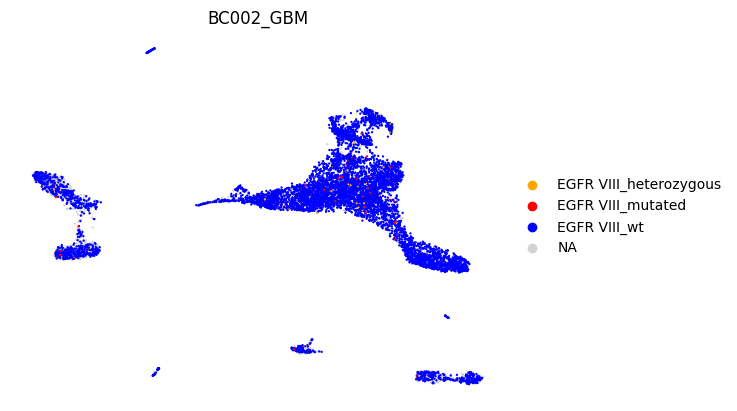

In [ ]:
lib = 'GBM'
BC = 'BC002'

sample = BC + '_' + lib
alt_gapfill_set = pd.read_csv(feature_set)
### 
alt_gapfill_set.loc[alt_gapfill_set['name'] == 'EGFR VIII','gapfill_from_transcriptome'] = 'GGC' ## temporary fix for EGFR VIII wt probe
### 
gf_dirs = {}

adata_path = large_data_dir + 'GBM_' + BC + '_genotyped.h5ad' ### this is just for cell names; it would not usually use the genotyped h5ad because it wouldn't be generated yet, but cell names are the same so we use it here to not have to upload a redundant h5ad just for this step
gf_dir = large_data_dir + 'gf_decrosslink_4plex/BC' + str(int(BC.replace('BC',''))) + '_giftwrap/'

min_percent_supporting = 0.9
collapse_across_probes = True

probe_reads = gf_utils.get_input_probe_reads(gf_dir, read_threshold = 0, adata_path = adata_path, min_percent_supporting=min_percent_supporting, collapse_across_probes=collapse_across_probes)

###
probe_reads.loc[(probe_reads['probe_idx'] == 21) & (probe_reads['gapfill'] == 'GGC'),'probe_idx'] = 383  ### temporary fix for EGFR VIII control probe idx
###

gapfill_likelihoods = pd.read_csv('output/likelihood_tables_with_null_' + lib + '/' + BC + '_gapfill_likelihoods.csv')
columns_to_rename = gapfill_likelihoods.columns.difference(['probe_idx', 'gapfill'])
gapfill_likelihoods.rename(columns={col: 'p_gapfill_given_' + col for col in columns_to_rename}, inplace=True)
###
gapfill_likelihoods = gapfill_likelihoods.loc[:,gapfill_likelihoods.columns.str.len() < 100] ### temporary fix for EGFR VIII control probe idx
###

pcr_swap_likelihoods = pd.read_csv('output/likelihood_tables_' + lib + '/patient_' + BC + '_swap_probabilities.csv')
pcr_swap_likelihoods.rename(columns={'likelihood':'no_pcr_swap_likelihood'}, inplace=True)
pcr_swap_likelihoods['pcr_swap_likelihood'] = 1 - pcr_swap_likelihoods['no_pcr_swap_likelihood']

if 'gapfill' not in gapfill_likelihoods.columns:
    gapfill_likelihoods['gapfill'] = np.nan

variant_probes = gapfill_likelihoods.loc[gapfill_likelihoods['gapfill'].notna(),'probe_idx'].unique()
if len(variant_probes) > 0:
    probe_reads1 = probe_reads.loc[probe_reads['probe_idx'].isin(variant_probes)]
    probe_reads1 = probe_reads1.merge(gapfill_likelihoods.loc[gapfill_likelihoods['gapfill'].notna()], how='left', on = ['probe_idx','gapfill'])

nonvariant_probes = gapfill_likelihoods.loc[~(gapfill_likelihoods['probe_idx'].isin(variant_probes)) & (gapfill_likelihoods['gapfill'].isna()),'probe_idx'].unique()
probe_reads2 = probe_reads.loc[probe_reads['probe_idx'].isin(nonvariant_probes)]
probe_reads2 = probe_reads2.merge(gapfill_likelihoods.loc[gapfill_likelihoods['gapfill'].isna()].drop('gapfill',axis=1), how='left', on = ['probe_idx'])

if len(variant_probes) == 0:
    probe_reads = probe_reads2.copy()
else:
    probe_reads = pd.concat([probe_reads1, probe_reads2], ignore_index=True).reset_index(drop=True)
probe_reads = probe_reads.merge(pcr_swap_likelihoods[['pcr_duplicate_count','pcr_swap_likelihood']], how='left', on = 'pcr_duplicate_count')
probe_reads.drop(['umi','percent_supporting','probe_barcode'],axis=1, inplace=True)

alt_genotypes = pd.read_csv('output/likelihood_tables_with_null_' + lib + '/' + BC + '_feature_set.csv')
alt_genotypes = alt_genotypes.loc[alt_genotypes['sample'] == sample].dropna(subset='HGVSc')
alt_genotypes['gapfill'] = alt_genotypes['gapfill'].fillna('')
alt_genotypes['name'] = alt_genotypes['HGVSc'].copy()

alt_genotypes = pd.concat([
    alt_genotypes[['probe_idx', 'name', 'gapfill']].rename(columns={'gapfill': 'gapfill_value'}).assign(variant=True),
    alt_genotypes[['probe_idx', 'name', 'gapfill_from_transcriptome']].rename(columns={'gapfill_from_transcriptome': 'gapfill_value'}).assign(variant=False)
], ignore_index=True)

alt_genotypes['gapfill_value'] = alt_genotypes['gapfill_value'].fillna('')

cell_genotypes = {}
for probe_idx in probe_reads['probe_idx'].unique():
    pr = probe_reads.loc[probe_reads['probe_idx'] == probe_idx].dropna(axis=1, how='all')
    pr = pr.loc[:,((pr != 0).sum() > 0) | ~(pr.columns.str.contains('p_'))]
    cell_genotypes[probe_idx] = get_cell_genotypes(probe_idx,pr, alt_genotypes.loc[alt_genotypes['probe_idx'] == probe_idx])

all_df = pd.DataFrame()
for probe_idx in cell_genotypes.keys():
    df = cell_genotypes[probe_idx].set_index('barcode').drop(['cell_idx'],axis=1)
    all_df = all_df.merge(df, how='outer', left_index=True, right_index=True)

adata = gf_utils.read_adata(adata_path)
adata.obsm['genotypes'] = all_df.reindex(adata.obs_names)

if 'EGFR VIII_mutated' in adata.obsm['genotypes'].columns:
    adata.obs['genotype'] = adata.obsm['genotypes'][['EGFR VIII_mutated','EGFR VIII_heterozygous','EGFR VIII_wt']].idxmax(axis=1)
else:
    adata.obs['genotype'] = adata.obsm['genotypes']['EGFR VIII_wt'].map({1: 'EGFR VIII_wt'})


In [ ]:
### save h5ad as _genotyped.h5ad

